In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets, linear_model, metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [ ]:
#this code block lets you run your code on your google drive
from google.colab import drive
drive.mount("/content/gdrive")
%cd /content/gdrive/MyDrive

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
/content/gdrive/MyDrive


In [ ]:
df =pd.read_csv('fake_news_dataset.csv')

In [ ]:
print(len(df))
print(df.head())
print(df.columns)

4000
   id            title        author  \
0   1  Breaking News 1    Jane Smith   
1   2  Breaking News 2   Emily Davis   
2   3  Breaking News 3      John Doe   
3   4  Breaking News 4  Alex Johnson   
4   5  Breaking News 5   Emily Davis   

                                                text           state  \
0  This is the content of article 1. It contains ...       Tennessee   
1  This is the content of article 2. It contains ...       Wisconsin   
2  This is the content of article 3. It contains ...        Missouri   
3  This is the content of article 4. It contains ...  North Carolina   
4  This is the content of article 5. It contains ...      California   

  date_published          source       category  sentiment_score  word_count  \
0     30-11-2021       The Onion  Entertainment            -0.22        1302   
1     02-09-2021    The Guardian     Technology             0.92         322   
2     13-04-2021  New York Times         Sports             0.25         228   
3

In [ ]:
df = df.drop('title', axis=1)
df = df.drop('id', axis=1)
df = df.drop('text', axis=1)
df = df.drop('author', axis=1)
df = df.drop('date_published', axis=1)
#df = df.drop('state', axis=1)
scaler = StandardScaler()

In [ ]:
print(df['source'].isnull().sum())
print(df['sentiment_score'].isnull().sum())
print(df['num_shares'].isnull().sum())
print(df['num_comments'].isnull().sum())
print(df['political_bias'].isnull().sum())

0
0
0
0
0


In [ ]:

#sns.pairplot(data=df)

In [ ]:
df = pd.get_dummies(df, columns=['state','source', 'political_bias', 'category', 'fact_check_rating','label'], drop_first=True, dtype=int)
print(df.head())
#I think we should get rid of satirical articles, as they are irrelevant to our goals. What does it mean for a satirical article to be real or fake>
print("Num Satirical: ",df["is_satirical"].sum())
#this will eliminate all satirical articles
df = df[df["is_satirical"] != 1]
#this eliminates the is_satirical column now that all entries should be 0
df = df.drop('is_satirical', axis=1)

   sentiment_score  word_count  char_count  has_images  has_videos  \
0            -0.22        1302        5070           0           0   
1             0.92         322        2722           1           0   
2             0.25         228        5904           0           1   
3             0.94         155         825           1           0   
4            -0.01         962        1087           1           0   

   readability_score  num_shares  num_comments  is_satirical  trust_score  \
0              66.18       47305           450             1           76   
1              41.10       39804           530             1            1   
2              30.04       45860           763             0           57   
3              75.16       34222           945             1           18   
4              43.90       35934           433             0           95   

   ...  political_bias_Left  political_bias_Right  category_Entertainment  \
0  ...                    0            

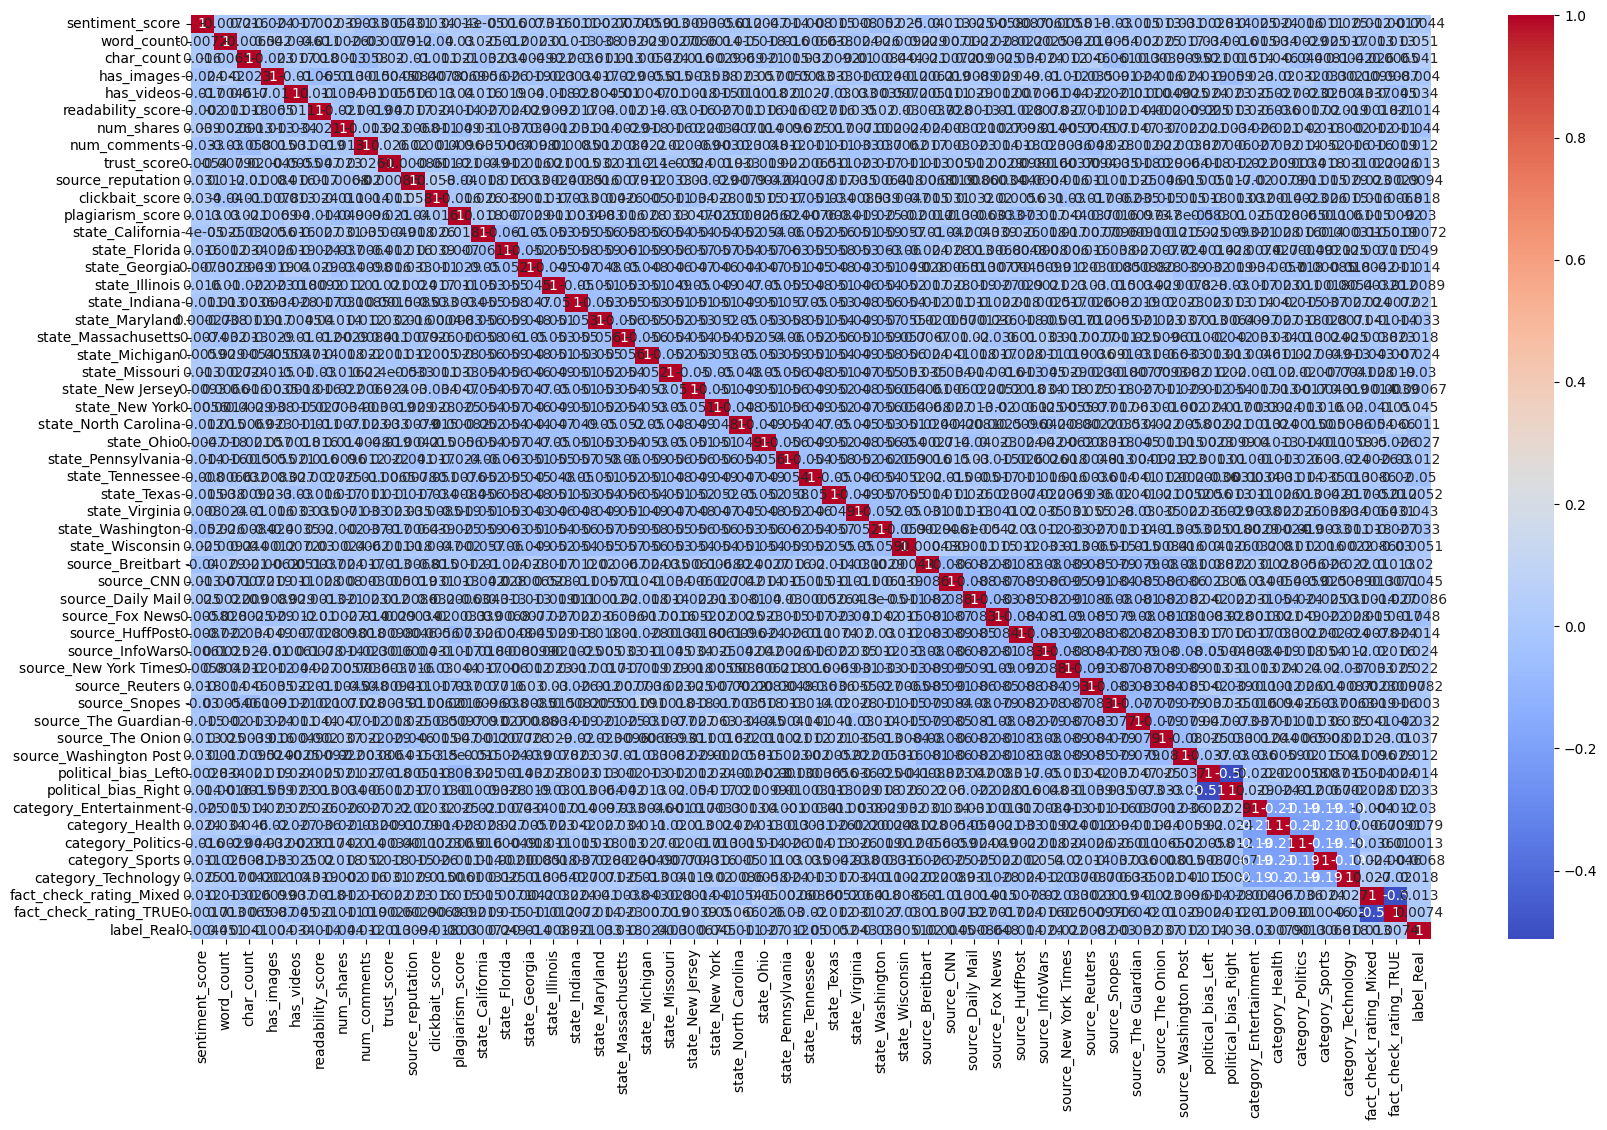

1003


In [ ]:
corr = df.corr()
plt.figure(figsize=(20, 12))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()
print(df["label_Real"].sum())

In [ ]:
print(len(df))
print("Total labelled real: ", df["label_Real"].sum())
#subset = df[['label_Real']]
lr = linear_model.LogisticRegression()
X = df.drop(['label_Real'], axis=1)
y = df['label_Real']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
lr.fit(x_train, y_train)
feature_names = X.columns
standardized_coefficients = pd.Series(lr.coef_[0], index=feature_names).sort_values(ascending=False)
print(standardized_coefficients)
y_pred = lr.predict(x_test)
y_pred_proba = lr.predict_proba(x_test)[:, 1]

2012
Total labelled real:  1003
political_bias_Right       0.133909
source_The Onion           0.130077
has_videos                 0.118723
source_New York Times      0.109429
political_bias_Left        0.095455
char_count                 0.093633
word_count                 0.089798
source_Reuters             0.060131
source_InfoWars            0.050246
source_CNN                 0.043930
source_Breitbart           0.041863
num_comments               0.030604
source_Washington Post     0.028785
fact_check_rating_TRUE     0.015887
fact_check_rating_Mixed    0.012371
source_reputation          0.009851
source_Daily Mail          0.009472
source_HuffPost            0.008550
sentiment_score            0.007709
category_Politics         -0.003053
trust_score               -0.003862
source_Snopes             -0.009525
plagiarism_score          -0.009545
readability_score         -0.011675
category_Technology       -0.024143
clickbait_score           -0.034168
category_Health           -0.040

In [ ]:
acc = metrics.accuracy_score(y_test, y_pred)
prec = metrics.precision_score(y_test, y_pred)
rec = metrics.recall_score(y_test, y_pred)
roc = metrics.roc_auc_score(y_test, y_pred_proba)
print("Accuracy: ", acc)
print("Precision: ", prec)
print("Recall: ", rec)
print("ROC: ", roc)

Accuracy:  0.5285359801488834
Precision:  0.5081967213114754
Recall:  0.48186528497409326
ROC:  0.5065383666419936


In [ ]:
rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)
y_pred = rf.predict(x_test)
y_pred_proba = rf.predict_proba(x_test)[:, 1]
acc = metrics.accuracy_score(y_test, y_pred)
prec = metrics.precision_score(y_test, y_pred)
rec = metrics.recall_score(y_test, y_pred)
roc = metrics.roc_auc_score(y_test, y_pred_proba)
print("Accuracy: ", acc)
print("Precision: ", prec)
print("Recall: ", rec)
print("ROC: ", roc)

Accuracy:  0.4987593052109181
Precision:  0.4742857142857143
Recall:  0.43005181347150256
ROC:  0.4954601529731064


In [ ]:
sv = SVC(probability=True)
sv.fit(x_train, y_train)
y_pred = sv.predict(x_test)
y_pred_proba = rf.predict_proba(x_test)[:, 1]
acc = metrics.accuracy_score(y_test, y_pred)
prec = metrics.precision_score(y_test, y_pred)
rec = metrics.recall_score(y_test, y_pred)
roc = metrics.roc_auc_score(y_test, y_pred_proba)
print("Accuracy: ", acc)
print("Precision: ", prec)
print("Recall: ", rec)
print("ROC: ", roc)

Accuracy:  0.49379652605459057
Precision:  0.4682080924855491
Recall:  0.41968911917098445
ROC:  0.4954601529731064


In [ ]:
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
y_pred_proba = rf.predict_proba(x_test)[:, 1]
acc = metrics.accuracy_score(y_test, y_pred)
prec = metrics.precision_score(y_test, y_pred)
rec = metrics.recall_score(y_test, y_pred)
roc = metrics.roc_auc_score(y_test, y_pred_proba)
print("Accuracy: ", acc)
print("Precision: ", prec)
print("Recall: ", rec)
print("ROC: ", roc)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [04:31:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy:  0.4913151364764268
Precision:  0.4673913043478261
Recall:  0.44559585492227977
ROC:  0.4954601529731064
